In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [8]:
from google.colab import files

uploaded = files.upload()

Saving ...final_dav_dataset_cleaned.csv to ...final_dav_dataset_cleaned.csv


In [9]:
import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully")
display(df.head())

Dataset loaded successfully


,Event Type,Attendees,Expenses,Success
0,Sports,853,35012,0
1,Cultural,670,159726,1
2,Cultural,1113,176284,1
3,Sports,1074,218188,1
4,Seminars,1013,192829,1


In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 5000
Number of columns: 4
Dataset shape: (5000, 4)


In [11]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Event Type', 'Attendees', 'Expenses', 'Success']


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Event Type  5000 non-null   object
 1   Attendees   5000 non-null   int64 
 2   Expenses    5000 non-null   int64 
 3   Success     5000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 156.4+ KB


In [13]:
df.describe()

,Attendees,Expenses,Success
count,5000.000000,5000.000000,5000.00000
mean,795.395000,89527.583400,0.92000
std,405.928268,66269.743684,0.27132
min,100.000000,2019.000000,0.00000
25%,438.000000,33377.000000,1.00000
50%,801.000000,74418.500000,1.00000
75%,1139.250000,135492.750000,1.00000
max,1500.000000,249764.000000,1.00000


In [14]:
print("Missing values in each column:")

print(df.isnull().sum())

Missing values in each column:
Event Type    0
Attendees     0
Expenses      0
Success       0
dtype: int64


In [15]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Event Type    0.0
Attendees     0.0
Expenses      0.0
Success       0.0
dtype: float64


In [16]:
missing_report = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

display(missing_report)

,Missing Count,Missing Percentage
Event Type,0,0.0
Attendees,0,0.0
Expenses,0,0.0
Success,0,0.0


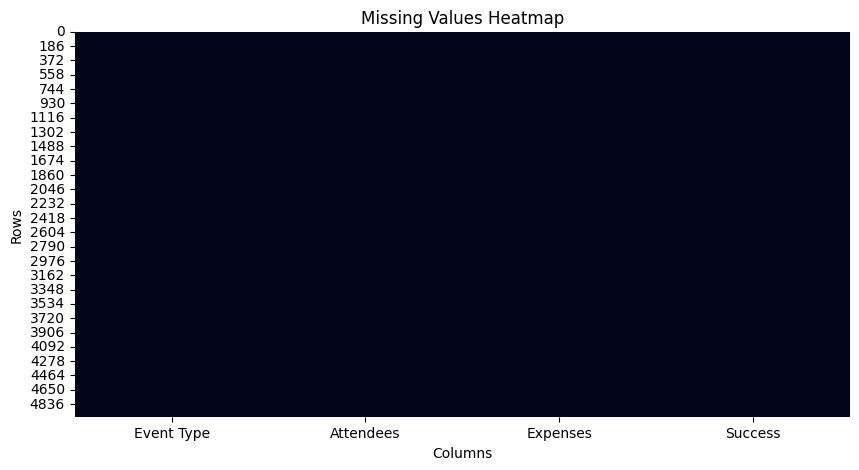

In [17]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

In [18]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns

# Fill numeric missing values with median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled")
print(df.isnull().sum())

Missing values handled
Event Type    0
Attendees     0
Expenses      0
Success       0
dtype: int64


In [20]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


In [21]:
duplicates = df[df.duplicated(keep=False)]

display(duplicates)

,Event Type,Attendees,Expenses,Success


In [22]:
print("Rows before:", len(df))

df = df.drop_duplicates()

print("Rows after:", len(df))

Rows before: 5000
Rows after: 5000


In [23]:
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


In [24]:
print(df["Event Type"].unique())

['Sports' 'Cultural' 'Seminars']


In [25]:
print(df["Event Type"].value_counts())

Event Type
Sports      1681
Cultural    1672
Seminars    1647
Name: count, dtype: int64


In [26]:
numeric_columns = ["Attendees", "Expenses", "Success"]

for col in numeric_columns:
    print(f"\n{col} zero count:", (df[col] == 0).sum())


Attendees zero count: 0

Expenses zero count: 0

Success zero count: 400


In [27]:
print("Negative attendees:", (df["Attendees"] < 0).sum())

print("Negative expenses:", (df["Expenses"] < 0).sum())

Negative attendees: 0
Negative expenses: 0


In [28]:
print("Success values:")
print(df["Success"].value_counts())

Success values:
Success
1    4600
0     400
Name: count, dtype: int64


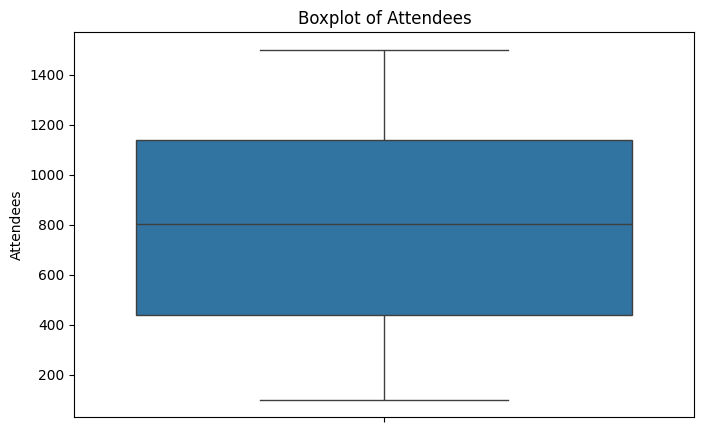

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["Attendees"])

plt.title("Boxplot of Attendees")

plt.show()

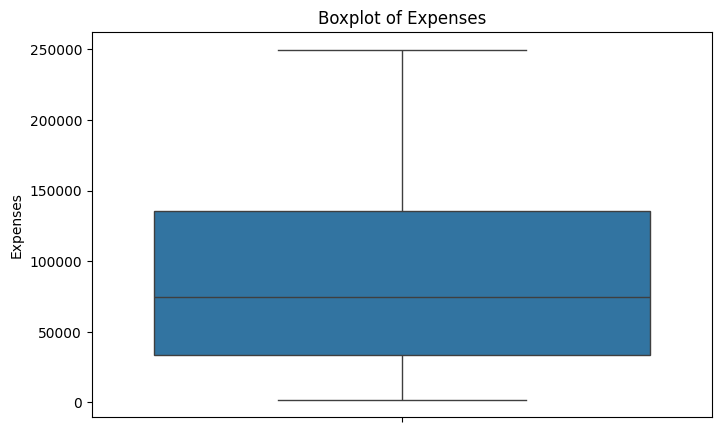

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["Expenses"])

plt.title("Boxplot of Expenses")

plt.show()

In [31]:
def detect_outliers(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Outliers:", len(outliers))

    return outliers

attendee_outliers = detect_outliers("Attendees")
expense_outliers = detect_outliers("Expenses")

Column: Attendees
Q1: 438.0
Q3: 1139.25
IQR: 701.25
Outliers: 0
Column: Expenses
Q1: 33377.0
Q3: 135492.75
IQR: 102115.75
Outliers: 0


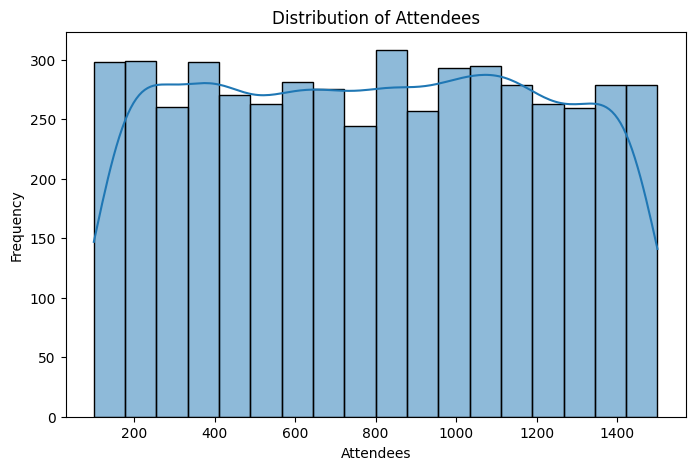

In [32]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Attendees"], kde=True)

plt.title("Distribution of Attendees")
plt.xlabel("Attendees")
plt.ylabel("Frequency")

plt.show()

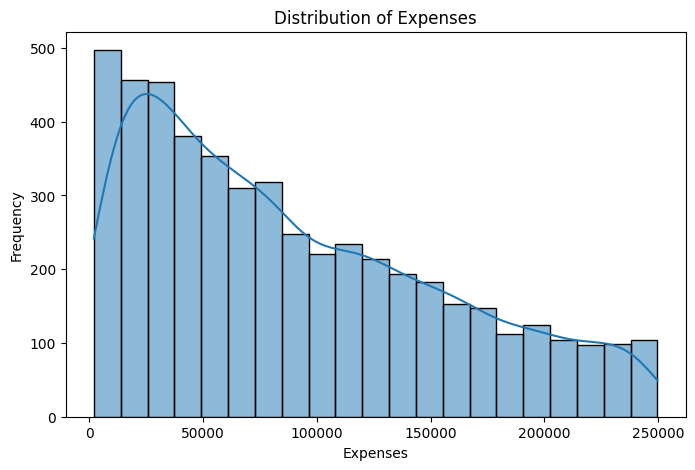

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Expenses"], kde=True)

plt.title("Distribution of Expenses")
plt.xlabel("Expenses")
plt.ylabel("Frequency")

plt.show()

In [34]:
print("Attendees skewness:", df["Attendees"].skew())

print("Expenses skewness:", df["Expenses"].skew())

Attendees skewness: 0.0050309142104971935
Expenses skewness: 0.6502639218831621


In [35]:
event_counts = df["Event Type"].value_counts()

display(event_counts)

,count
Event Type,
Sports,1681
Cultural,1672
Seminars,1647


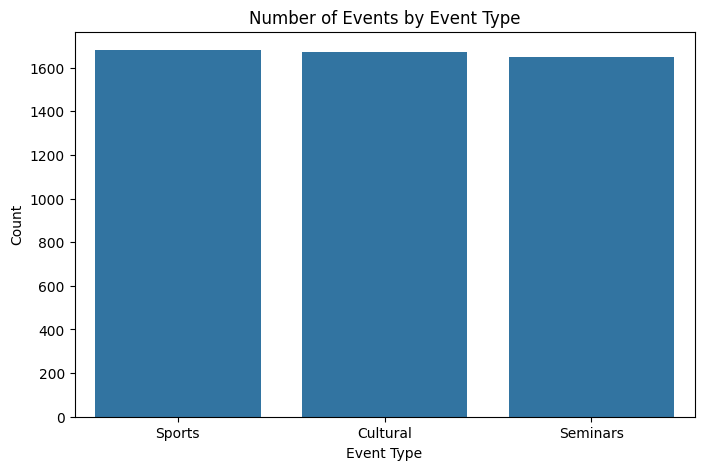

In [36]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Event Type"
)

plt.title("Number of Events by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.show()

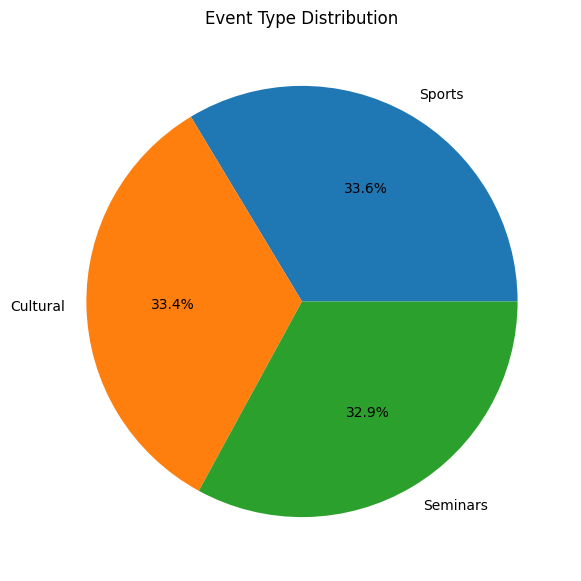

In [37]:
df["Event Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7, 7)
)

plt.title("Event Type Distribution")
plt.ylabel("")

plt.show()

In [38]:
print("Total attendees:", df["Attendees"].sum())

print("Average attendees:", df["Attendees"].mean())

print("Maximum attendees:", df["Attendees"].max())

print("Minimum attendees:", df["Attendees"].min())

Total attendees: 3976975
Average attendees: 795.395
Maximum attendees: 1500
Minimum attendees: 100


In [39]:
attendance_by_event = df.groupby(
    "Event Type"
)["Attendees"].agg([
    "sum",
    "mean",
    "min",
    "max"
])

display(attendance_by_event)

,sum,mean,min,max
Event Type,,,,
Cultural,1355823,810.898923,100,1497
Seminars,1282177,778.492410,100,1500
Sports,1338975,796.534801,101,1500


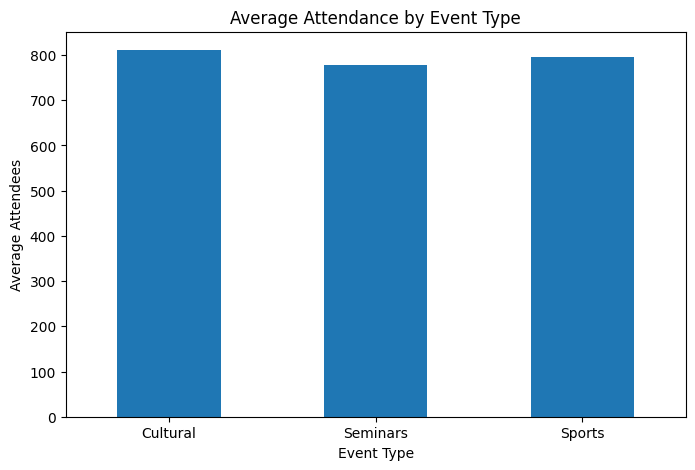

In [40]:
df.groupby("Event Type")["Attendees"].mean().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Attendance by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average Attendees")

plt.xticks(rotation=0)

plt.show()

In [41]:
success_count = (df["Success"] == 1).sum()

unsuccess_count = (df["Success"] == 0).sum()

total_count = len(df)

print("Successful:", success_count)

print("Unsuccessful:", unsuccess_count)

print("Total:", total_count)

Successful: 4600
Unsuccessful: 400
Total: 5000


In [42]:
success_percentage = (
    success_count / total_count
) * 100

print(f"Success Percentage: {success_percentage:.2f}%")

Success Percentage: 92.00%


In [43]:
unsuccess_percentage = (
    unsuccess_count / total_count
) * 100

print(f"Unsuccessful Percentage: {unsuccess_percentage:.2f}%")

Unsuccessful Percentage: 8.00%


In [44]:
total_percentage = (
    total_count / total_count
) * 100

print(f"Total Percentage: {total_percentage:.2f}%")

Total Percentage: 100.00%


In [45]:
success_analysis = pd.DataFrame({
    "Category": [
        "Successful",
        "Unsuccessful",
        "Total"
    ],

    "Count": [
        success_count,
        unsuccess_count,
        total_count
    ],

    "Percentage": [
        success_percentage,
        unsuccess_percentage,
        total_percentage
    ]
})

success_analysis["Percentage"] = (
    success_analysis["Percentage"].round(2)
)

display(success_analysis)

,Category,Count,Percentage
0,Successful,4600,92.0
1,Unsuccessful,400,8.0
2,Total,5000,100.0


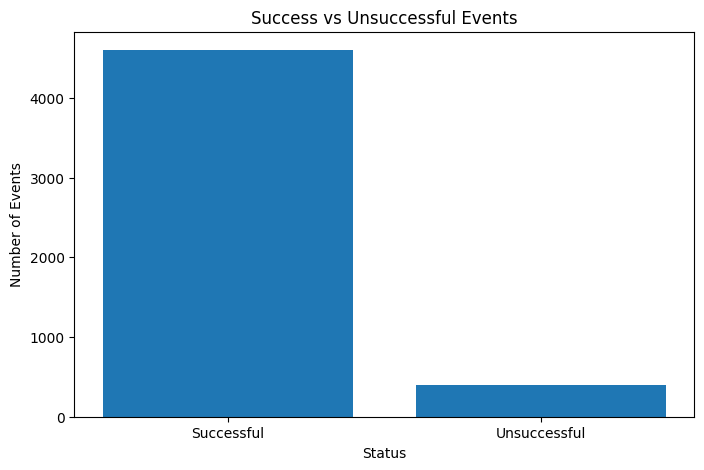

In [46]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Successful", "Unsuccessful"],
    [success_count, unsuccess_count]
)

plt.title("Success vs Unsuccessful Events")
plt.xlabel("Status")
plt.ylabel("Number of Events")

plt.show()

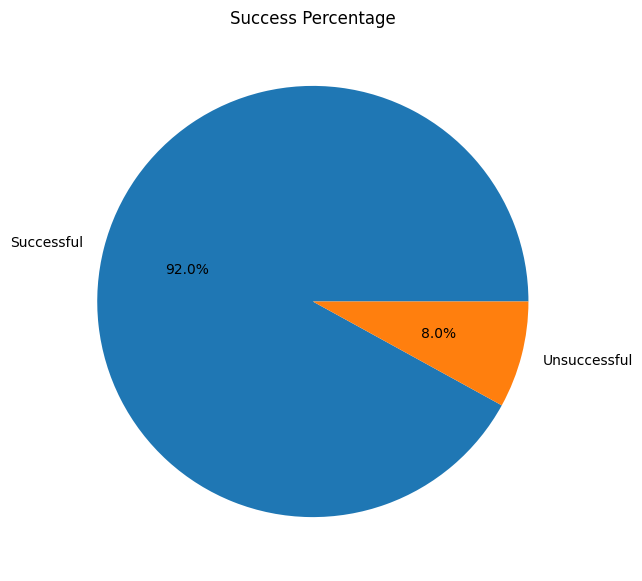

In [47]:
plt.figure(figsize=(7, 7))

plt.pie(
    [success_count, unsuccess_count],
    labels=["Successful", "Unsuccessful"],
    autopct="%1.1f%%"
)

plt.title("Success Percentage")

plt.show()

In [48]:
success_by_event = pd.crosstab(
    df["Event Type"],
    df["Success"]
)

success_by_event.columns = [
    "Unsuccessful",
    "Successful"
]

display(success_by_event)

,Unsuccessful,Successful
Event Type,,
Cultural,141,1531
Seminars,124,1523
Sports,135,1546


In [49]:
success_rate = df.groupby(
    "Event Type"
)["Success"].mean() * 100

success_rate = success_rate.round(2)

display(success_rate)

,Success
Event Type,
Cultural,91.57
Seminars,92.47
Sports,91.97


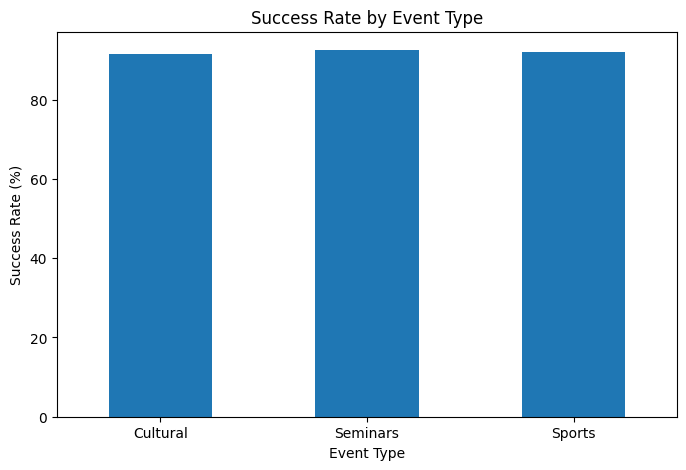

In [50]:
plt.figure(figsize=(8, 5))

success_rate.plot(kind="bar")

plt.title("Success Rate by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Success Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [51]:
print("Total expenses:", df["Expenses"].sum())

print("Average expenses:", df["Expenses"].mean())

print("Maximum expenses:", df["Expenses"].max())

print("Minimum expenses:", df["Expenses"].min())

Total expenses: 447637917
Average expenses: 89527.5834
Maximum expenses: 249764
Minimum expenses: 2019


In [52]:
expenses_by_event = df.groupby(
    "Event Type"
)["Expenses"].agg([
    "sum",
    "mean",
    "min",
    "max"
])

display(expenses_by_event)

,sum,mean,min,max
Event Type,,,,
Cultural,151268520,90471.602871,2115,249764
Seminars,146800887,89132.293260,2019,249439
Sports,149568510,88975.913147,2149,249614


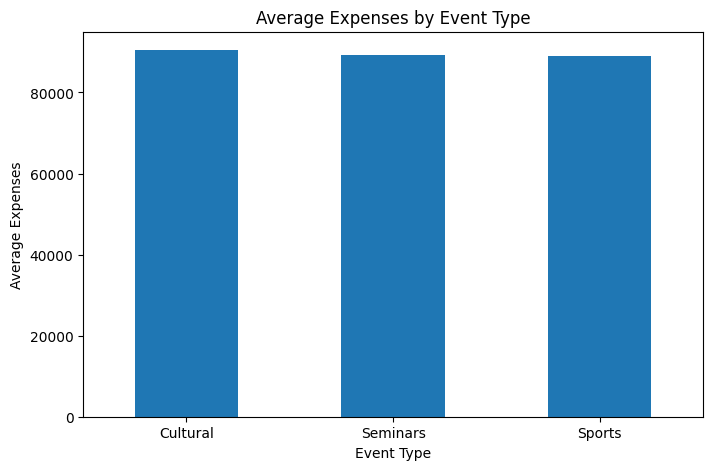

In [53]:
df.groupby("Event Type")["Expenses"].mean().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Expenses by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average Expenses")

plt.xticks(rotation=0)

plt.show()

In [54]:
correlation = df[
    ["Attendees", "Expenses", "Success"]
].corr()

display(correlation)

,Attendees,Expenses,Success
Attendees,1.000000,0.544635,-0.067541
Expenses,0.544635,1.000000,0.290566
Success,-0.067541,0.290566,1.000000


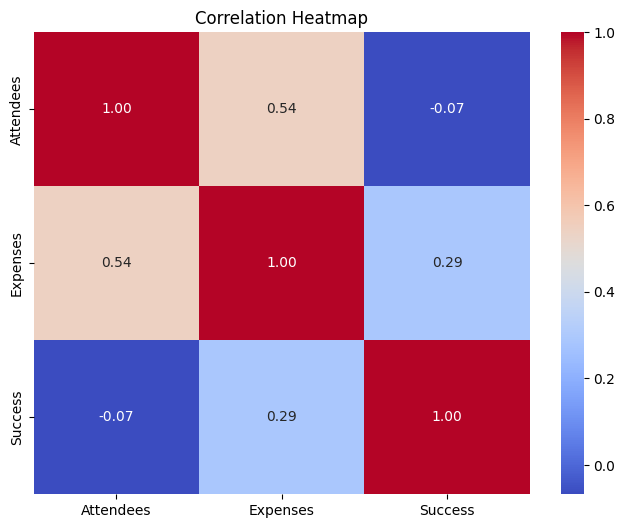

In [55]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [56]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Final dataset shape: (5000, 4)

Missing values:
Event Type    0
Attendees     0
Expenses      0
Success       0
dtype: int64

Duplicate rows: 0

Data types:
Event Type    object
Attendees      int64
Expenses       int64
Success        int64
dtype: object


In [57]:
display(df.head(10))

,Event Type,Attendees,Expenses,Success
0,Sports,853,35012,0
1,Cultural,670,159726,1
2,Cultural,1113,176284,1
3,Sports,1074,218188,1
4,Seminars,1013,192829,1
5,Cultural,1155,59090,1
6,Sports,983,106178,1
7,Cultural,385,75390,1
8,Seminars,1011,92669,1
9,Cultural,399,19903,0


In [58]:
output_file = "event_attendance_cleaned_final.csv"

df.to_csv(
    output_file,
    index=False
)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [60]:
from google.colab import files

files.download(
    "event_attendance_cleaned_final.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The Event Attendance Dataset was analyzed using Python and Pandas in Google Colab. Data profiling, missing value analysis, duplicate detection, data validation, outlier detection, statistical analysis, and visualization were performed. Event attendance, expenses, and success rates were analyzed to understand event performance and identify useful patterns in the dataset.